# 手搓多元线性回归 — 加州房价数据集
> 从零实现正规方程法，不调 sklearn 的 LinearRegression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False     #防止中文乱码

In [2]:
# 加载加州房价数据（OpenML源，和 sklearn.fetch_california_housing 同款）被墙了，只能用这个
housing = fetch_openml(name="california_housing", version=1, parser="auto")

# 只取数值特征，去掉 ocean_proximity（文本列）   选取八个影响因素
numeric_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income"]
X = housing.data[numeric_cols].values.astype(np.float64)  #把这些指定的数据列的的数组元素类型转换为浮点数
y = housing.target.values.astype(np.float64)   #选择中位数

# 填充缺失值（total_bedrooms 有207个空）
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

print(f"数据量: {X.shape[0]} 条")
print(f"特征数: {X.shape[1]} 个")
print(f"特征名: {numeric_cols}")
print(f"目标均值: {y.mean():.2f} 美元")
print(f"目标范围: {y.min():.0f} ~ {y.max():.0f} 美元")


数据量: 20640 条
特征数: 8 个
特征名: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
目标均值: 206855.82 美元
目标范围: 14999 ~ 500001 美元


In [3]:
# 切分 & 标准化    划分训练集和测试集   测试集0.2   固定随机42个
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()   #标准化，同意转换成为标准正态分布
X_train = scaler.fit_transform(X_train)   #   标准化训练集
X_test  = scaler.transform(X_test)      ##使用训练集的均值和标准差标准化测试及

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")

训练集: (16512, 8)
测试集: (4128, 8)


---
## 核心：手写 MyLinearRegression

正规方程解：**$\theta = (X^T X)^{-1} X^T y$**

- `fit()`：给 X 前面拼一列 1 做截距项，然后套公式
- `predict()`：X @ coef + intercept

In [4]:
class MyLinearRegression:
    """手写多元线性回归 — 正规方程法"""

    def __init__(self):
        self.coef_ = None       # 权重（斜率） 八个参数
        self.intercept_ = None  # 截距    b

    def fit(self, X, y):
        # 给 X 左边拼一列 1，对应截距项
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])

        # 正规方程: θ = (XᵀX)⁻¹ Xᵀy
        theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

In [5]:
# 训练
model = MyLinearRegression()
model.fit(X_train, y_train)    #训练模型 

print(f"截距: {model.intercept_:.2f}")   
print()
for name, coef in zip(numeric_cols, model.coef_):
    print(f"  {name:20s}: {coef:>10.2f}")  #打印八个特征系数   保留两位小数

截距: 207194.69

  longitude           :  -85503.22
  latitude            :  -90698.85
  housing_median_age  :   14905.91
  total_rooms         :  -17805.42
  total_bedrooms      :   48712.34
  population          :  -43766.49
  households          :   17654.50
  median_income       :   77194.70


In [6]:
# 预测 & 手算评估指标
y_train_pred = model.predict(X_train)    #训练集
y_test_pred  = model.predict(X_test)     #测试集

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)  #预测值与真实值插值的平方均值

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))    #恢复原始数据单位

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot      #决定系数R**2

print("=" * 40)
print("训练集")
print(f"  MSE : {mse(y_train, y_train_pred):.2f}")
print(f"  RMSE: {rmse(y_train, y_train_pred):.2f}")
print(f"  R²  : {r2(y_train, y_train_pred):.4f}")
print()
print("测试集")
print(f"  MSE : {mse(y_test, y_test_pred):.2f}")
print(f"  RMSE: {rmse(y_test, y_test_pred):.2f}")
print(f"  R²  : {r2(y_test, y_test_pred):.4f}")

训练集
  MSE : 4811134397.88
  RMSE: 69362.34
  R²  : 0.6401

测试集
  MSE : 5059928371.17
  RMSE: 71133.17
  R²  : 0.6139


---
## 可视化

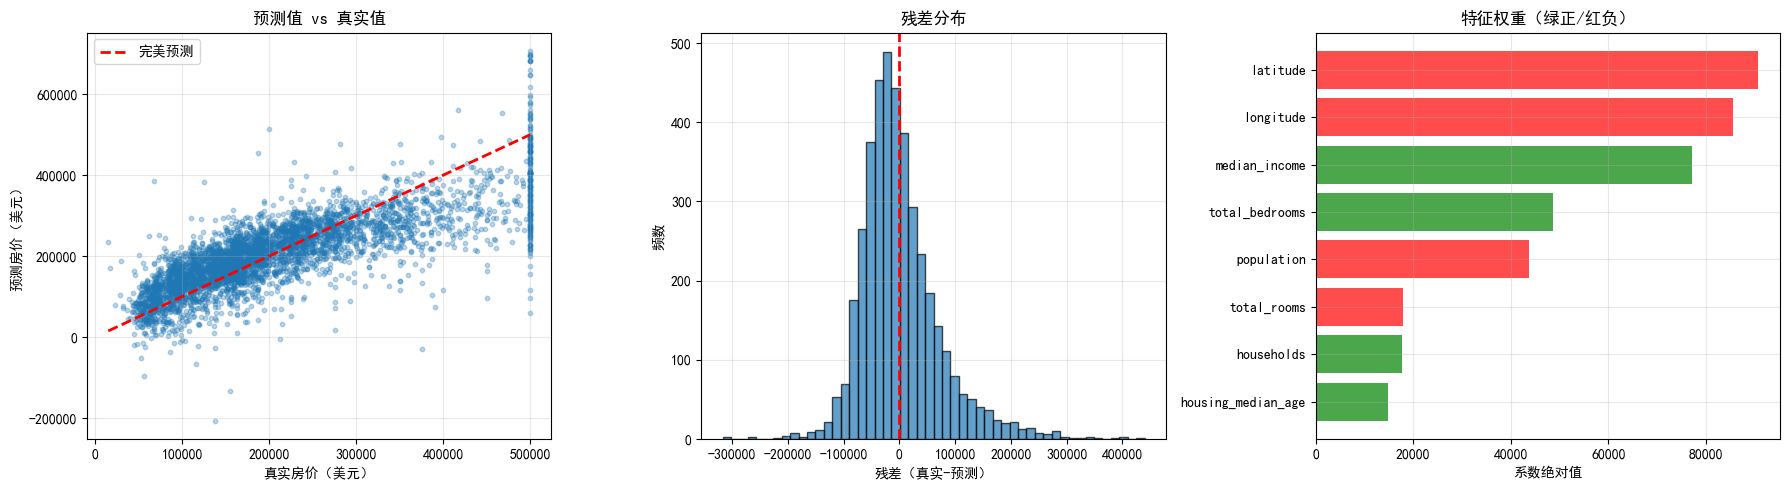

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1: 预测值 vs 真实值
ax = axes[0]
ax.scatter(y_test, y_test_pred, alpha=0.3, s=10)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='完美预测')
ax.set_xlabel('真实房价（美元）')
ax.set_ylabel('预测房价（美元）')
ax.set_title('预测值 vs 真实值')
ax.legend()
ax.grid(True, alpha=0.3)

# 图2: 残差分布
ax = axes[1]
residuals = y_test - y_test_pred
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('残差（真实-预测）')
ax.set_ylabel('频数')
ax.set_title('残差分布')
ax.grid(True, alpha=0.3)

# 图3: 特征系数（权重）
ax = axes[2]
coef_abs = np.abs(model.coef_)
idx = np.argsort(coef_abs)
colors = ['green' if c > 0 else 'red' for c in model.coef_[idx]]
ax.barh(range(len(numeric_cols)), coef_abs[idx], color=colors, alpha=0.7)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels([numeric_cols[i] for i in idx])
ax.set_xlabel('系数绝对值')
ax.set_title('特征权重（绿正/红负）')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 手撕公式 vs sklearn 验证

In [8]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print("sklearn R²:", r2(y_test, sk_pred).round(4))
print("手搓   R²:", r2(y_test, y_test_pred).round(4))
print()
print("系数差异（应接近0）:")
print(np.abs(sk_model.coef_ - model.coef_).round(6))

sklearn R²: 0.6139
手搓   R²: 0.6139

系数差异（应接近0）:
[0. 0. 0. 0. 0. 0. 0. 0.]
